1️⃣ Setup Environment

In [1]:
import os
import sys

# Fix project root path
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

print("Project Root:", ROOT_DIR)

Project Root: e:\Job-Related-Git-Repos\superstore-analytics-engine


2️⃣ Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

from src.data_loader import load_data
from src.preprocess import preprocess_data
from src.analysis import rfm_segmentation
from src.plots import sales_trend, return_rate_plot

3️⃣ Load Dataset

In [5]:
file_path = "../data/indian_superstore_data.xlsx"

orders, people, returns = load_data(file_path)

print("Orders shape:", orders.shape)
print("People shape:", people.shape)
print("Returns shape:", returns.shape)

Orders shape: (9994, 23)
People shape: (4, 2)
Returns shape: (800, 2)


4️⃣ Preprocess Data

In [7]:
df = preprocess_data(orders, people, returns)

print("Final dataset shape:", df.shape)
df.head(3)

Final dataset shape: (9994, 26)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Phone Number,Segment,Country/Region,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Regional Manager,Returned,Days_to_Ship
0,1,CA-2021-152156,2021-11-08,2021-11-11,Second Class,CG-12520,Aadhya Chowdhury,+91 7884077896,Consumer,India,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,Deepika Khanna,No,3
1,2,CA-2021-152156,2021-11-08,2021-11-11,Second Class,CG-12520,Aadhya Chowdhury,+91 6894921487,Consumer,India,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,Deepika Khanna,No,3
2,3,CA-2021-138688,2021-06-12,2021-06-16,Second Class,DV-13045,Sai Yadav,+91 8403761048,Corporate,India,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,Navya Nair,No,4


5️⃣ Basic Dataset Insights
##### Sales by Region

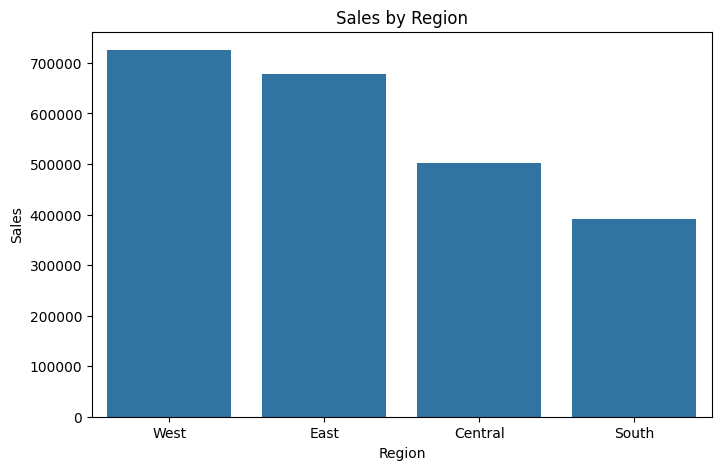

In [8]:
sales_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=sales_region.index, y=sales_region.values)
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

Top Categories by Sales

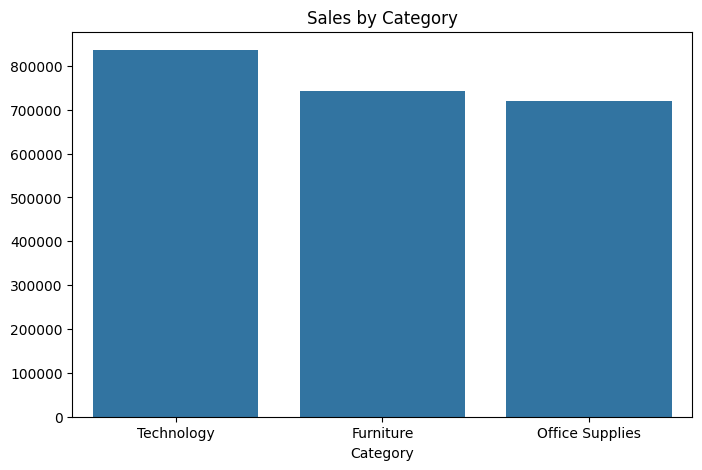

In [9]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Category")
plt.show()

6️⃣ Monthly Sales Trend

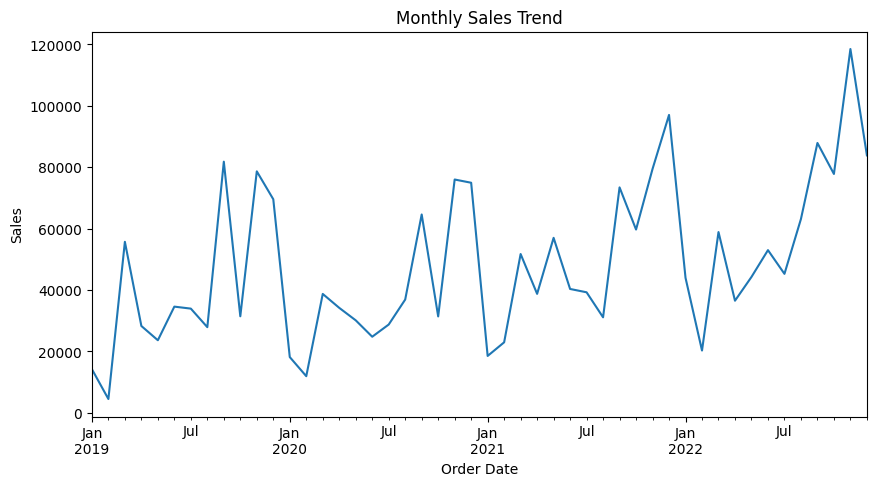

In [10]:
fig = sales_trend(df)
plt.show()

7️⃣ Return Rate Analysis

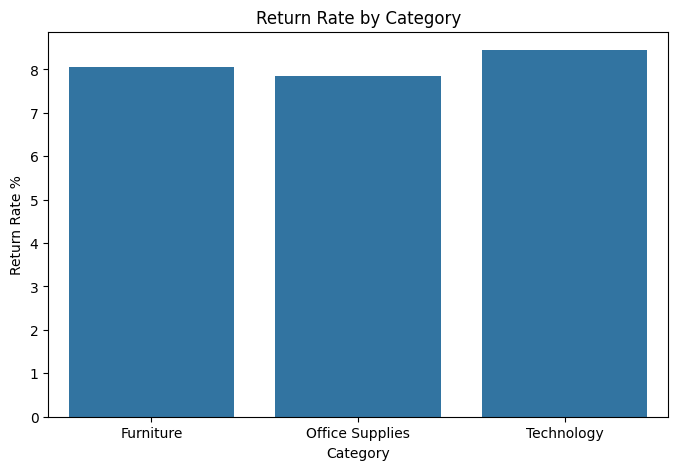

In [11]:
fig = return_rate_plot(df)
plt.show()

8️⃣ Customer Segmentation (RFM)

In [12]:
rfm = rfm_segmentation(df)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
AA-10315,184,11,5563.560,1
AA-10375,19,15,1056.390,3
AA-10480,259,12,1790.512,1
AA-10645,55,18,5086.935,0
AB-10015,415,6,886.156,1


Cluster distribution:

In [13]:
rfm["Cluster"].value_counts()

Cluster
1    262
0    241
3    185
2    105
Name: count, dtype: int64

Visualize clusters:

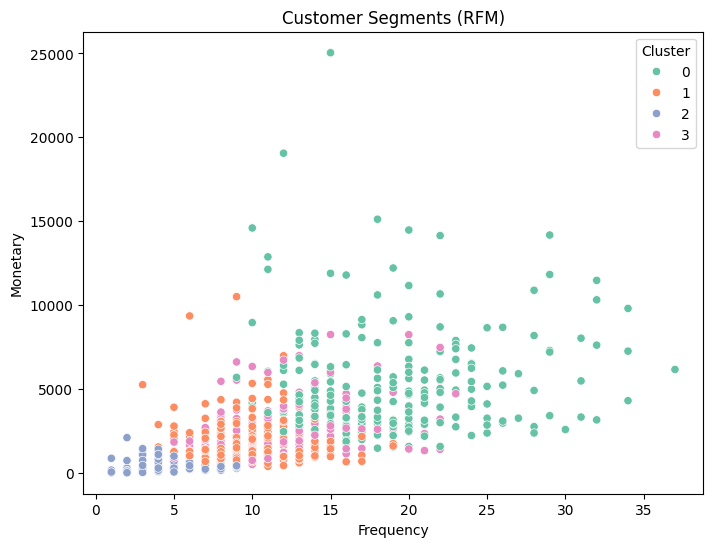

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments (RFM)")
plt.show()

9️⃣ Top Customers

In [15]:
rfm.sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
SM-20320,79,15,25043.050,0
TC-20980,399,12,19052.218,0
RB-19360,96,18,15117.339,0
TA-21385,69,10,14595.620,0
AB-10105,41,20,14473.571,0
KL-16645,47,29,14175.229,0
SC-20095,349,22,14142.334,0
HL-15040,43,11,12873.298,0
SE-20110,9,19,12209.438,0


🔟 Save Processed Dataset (Optional)

In [16]:
# df.to_csv("../data/processed_superstore.csv", index=False)